# 1. Импорт библиотек

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 2. Загрузка датасета и первичный просмотр

In [16]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

print("Первые 5 строк датасета:")
print(X.head())

print("\nРазмерность признаков:", X.shape)
print("Размерность целевого признака:", y.shape)

print("\nНазвания классов:")
print(iris.target_names)

Первые 5 строк датасета:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Размерность признаков: (150, 4)
Размерность целевого признака: (150,)

Названия классов:
['setosa' 'versicolor' 'virginica']


# 3. Проверка пропусков и общей информации о данных

In [17]:
print("Информация о датасете:")
print(X.info())

print("\nКоличество пропусков в каждом столбце:")
print(X.isnull().sum())

print("\nОписательная статистика:")
print(X.describe())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Количество пропусков в каждом столбце:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Описательная статистика:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000  

# 4. Визуальный анализ датасета

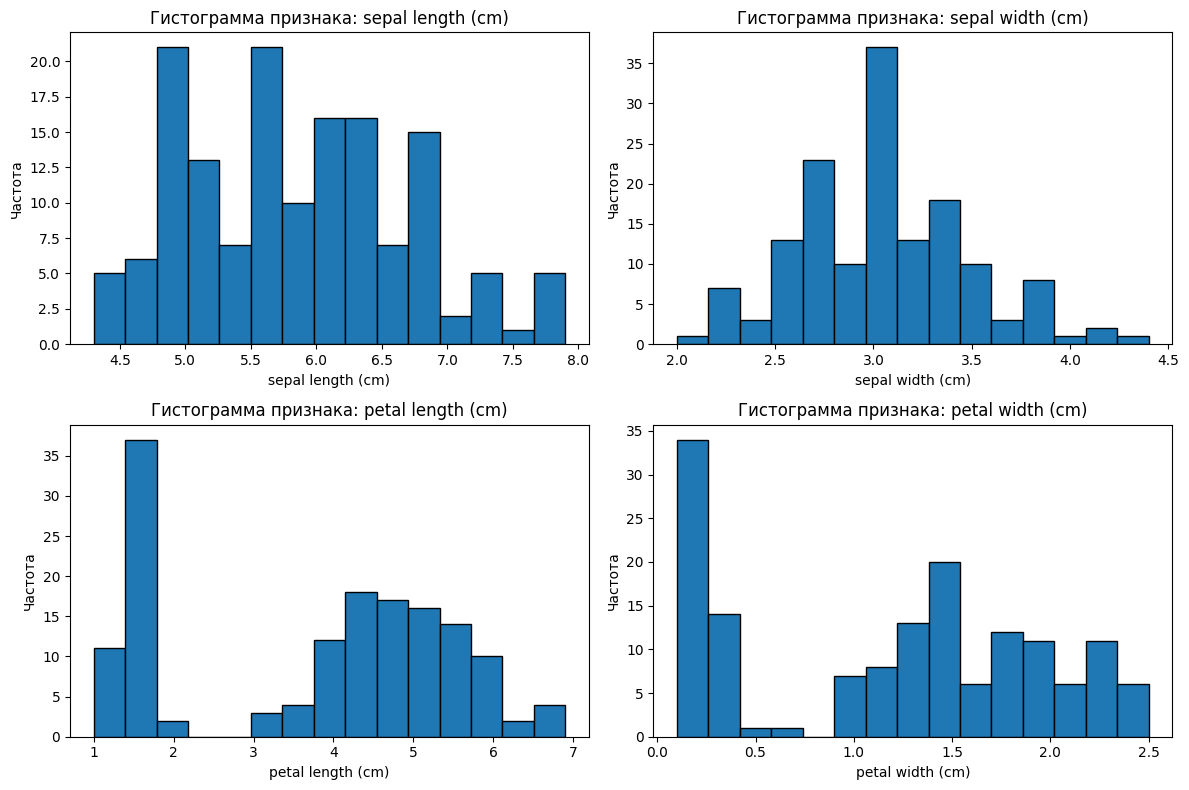

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=15, edgecolor='black')
    axes[i].set_title(f'Гистограмма признака: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# 5. Диаграмма рассеяния двух важных признаков

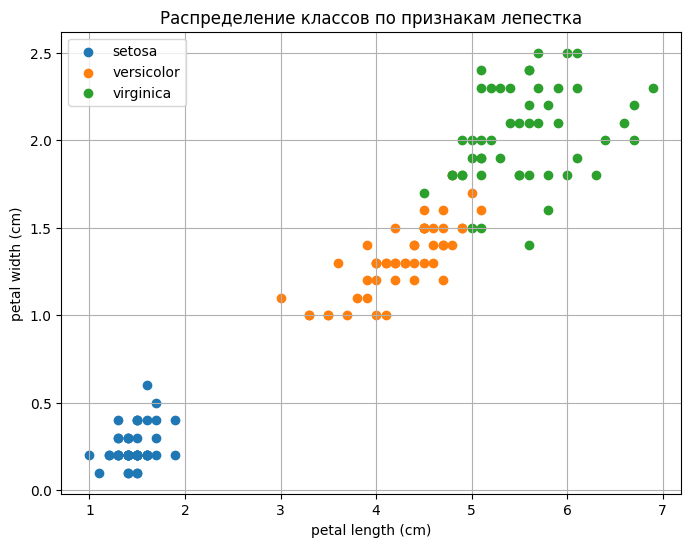

In [19]:
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(iris.target_names):
    plt.scatter(
        X[y == class_value]['petal length (cm)'],
        X[y == class_value]['petal width (cm)'],
        label=class_name
    )

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Распределение классов по признакам лепестка')
plt.legend()
plt.grid(True)
plt.show()

# 6. Разделение выборки на обучающую и тестовую

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

print("\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts().sort_index())

print("\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts().sort_index())

Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)

Распределение классов в обучающей выборке:
target
0    35
1    35
2    35
Name: count, dtype: int64

Распределение классов в тестовой выборке:
target
0    15
1    15
2    15
Name: count, dtype: int64


# 7. Создание моделей

In [21]:
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

# 8. Обучение моделей

In [22]:
log_reg_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

print("Модели успешно обучены.")

Модели успешно обучены.


# 9. Получение предсказаний

In [23]:
y_pred_log = log_reg_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

print("Предсказания получены.")

Предсказания получены.


# 10. Оценка качества моделей по двум метрикам

In [24]:
results = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'SVM', 'Дерево решений'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_log, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro')
    ]
})

print("Сравнение моделей:")
print(results)

Сравнение моделей:
                    Модель  Accuracy  F1-score (macro)
0  Логистическая регрессия  0.911111          0.910714
1                      SVM  0.933333          0.933259
2           Дерево решений  0.977778          0.977753


# 11. График сравнения моделей по Accuracy

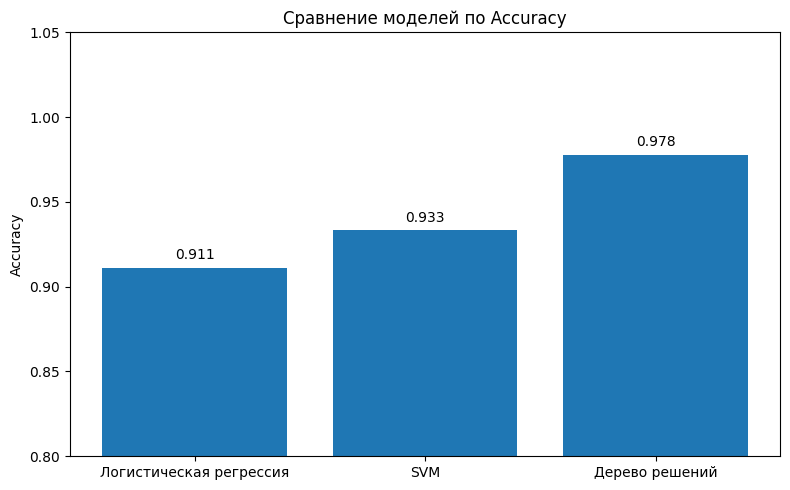

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(results['Модель'], results['Accuracy'])
plt.title('Сравнение моделей по Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.05)

for i, value in enumerate(results['Accuracy']):
    plt.text(i, value + 0.005, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

# 12. График сравнения моделей по F1-score

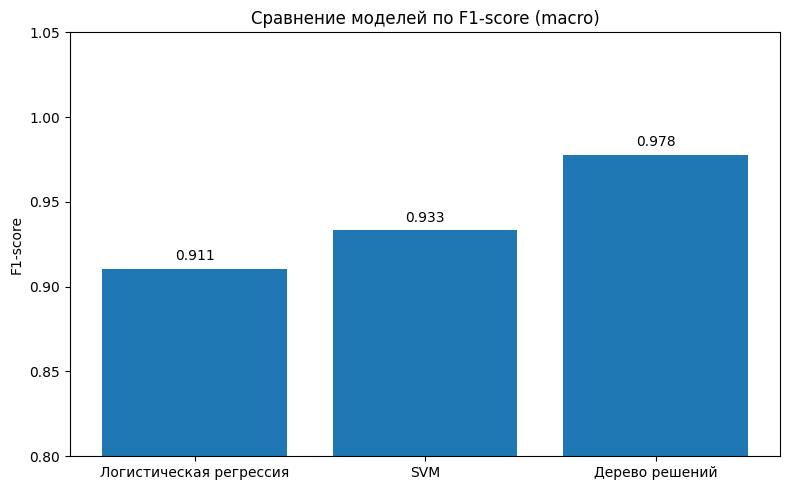

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(results['Модель'], results['F1-score (macro)'])
plt.title('Сравнение моделей по F1-score (macro)')
plt.ylabel('F1-score')
plt.ylim(0.8, 1.05)

for i, value in enumerate(results['F1-score (macro)']):
    plt.text(i, value + 0.005, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

# 13. Подробные classification report

In [27]:
print("Логистическая регрессия:")
print(classification_report(y_test, y_pred_log, target_names=iris.target_names))

print("SVM:")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))

print("Дерево решений:")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

Логистическая регрессия:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

SVM:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Дерево решений:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      

# 14. Матрица ошибок для логистической регрессии

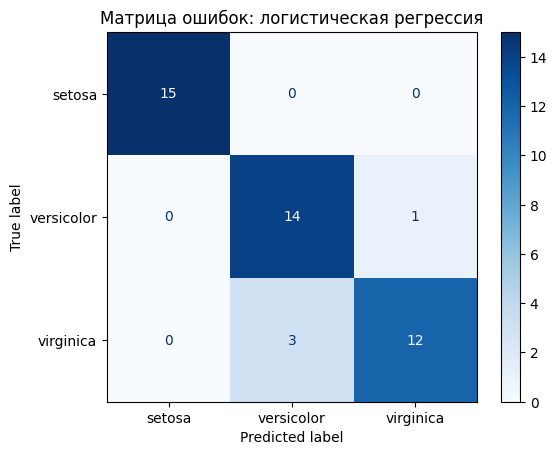

In [28]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: логистическая регрессия')
plt.show()

# 15. Матрица ошибок для SVM

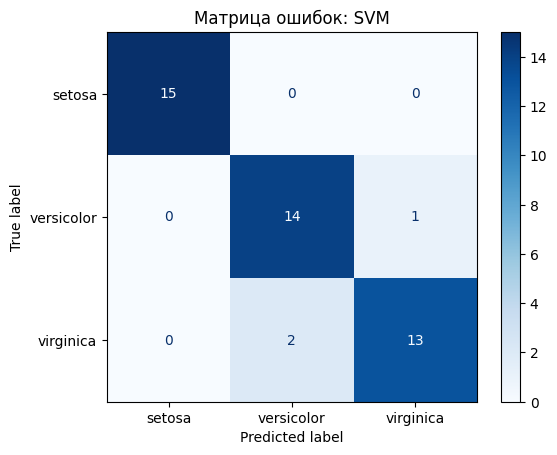

In [29]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: SVM')
plt.show()

# 16. Матрица ошибок для дерева решений

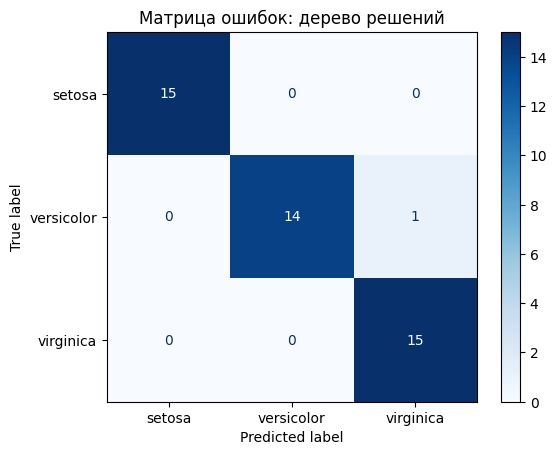

In [30]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: дерево решений')
plt.show()

# 17. График важности признаков для дерева решений

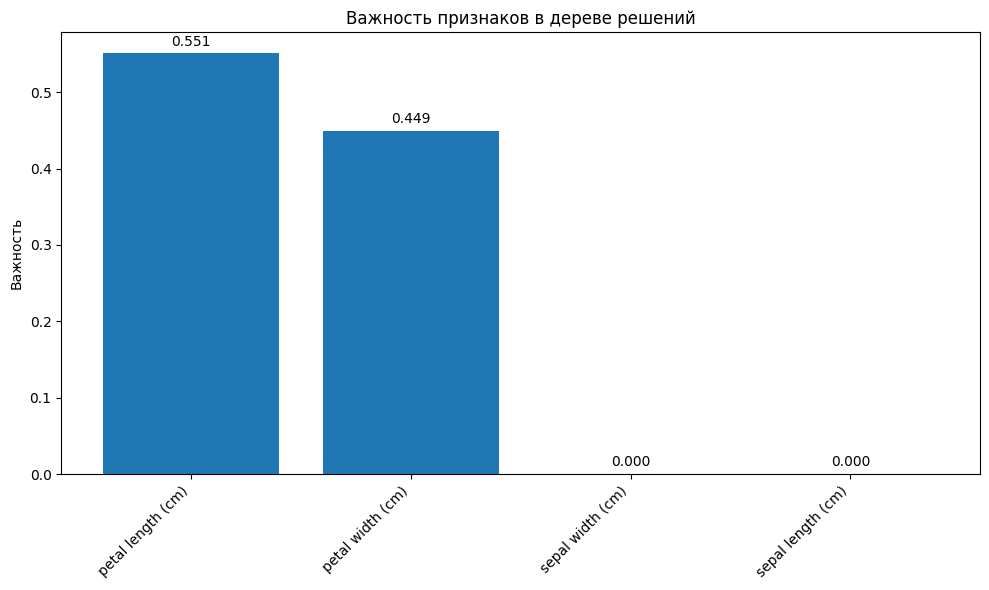

Важность признаков:
petal length (cm): 0.5509
petal width (cm): 0.4491
sepal width (cm): 0.0000
sepal length (cm): 0.0000


In [31]:
importances = tree_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.title('Важность признаков в дереве решений')
plt.ylabel('Важность')

for i, value in enumerate(importances[indices]):
    plt.text(i, value + 0.01, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

print("Важность признаков:")
for idx in indices:
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")

# 18. Визуализация дерева решений

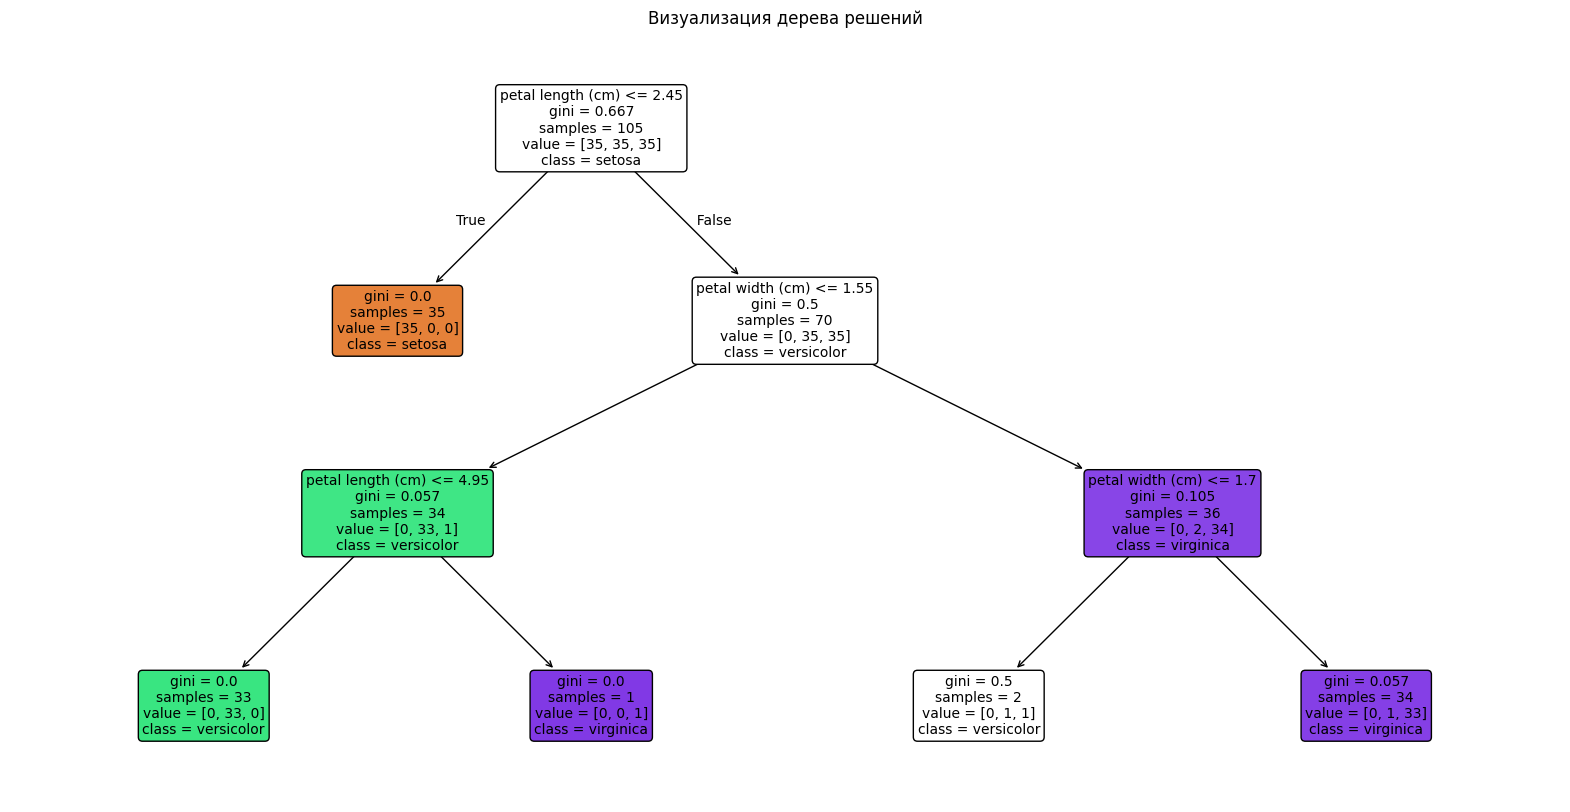

In [32]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Визуализация дерева решений')
plt.show()

# 19. Вывод правил дерева решений в текстовом виде

In [33]:
tree_rules = export_text(tree_model, feature_names=list(X.columns))
print("Правила дерева решений:")
print(tree_rules)

Правила дерева решений:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



# 20. Итоговый вывод в консоли

In [34]:
best_model = results.sort_values(by='Accuracy', ascending=False).iloc[0]

print("\nИТОГОВЫЙ ВЫВОД")
print(f"Лучшая модель по Accuracy: {best_model['Модель']}")
print("Все три модели показали высокое качество классификации на датасете Iris.")
print("Дерево решений дополнительно позволило определить важность признаков и визуализировать процесс принятия решений.")


ИТОГОВЫЙ ВЫВОД
Лучшая модель по Accuracy: Дерево решений
Все три модели показали высокое качество классификации на датасете Iris.
Дерево решений дополнительно позволило определить важность признаков и визуализировать процесс принятия решений.
